# 04 — Model Training

This notebook trains **Random Forest** and **XGBoost** classifiers to detect mining activity from merged remote-sensing features. We pay special attention to **spatial autocorrelation**: nearby pixels share similar spectral, topographic, and contextual properties simply because they are close together, not because the model has learned a meaningful pattern. A naive random train/test split would leak spatial information and inflate performance metrics.

To guard against this we:
1. Partition the study area into **spatial blocks** (KMeans on coordinates).
2. Hold out entire blocks for testing so no training point neighbours a test point.
3. Use **GroupKFold** cross-validation with blocks as groups on the training set.

---

## 1. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, RandomizedSearchCV, cross_val_score
from sklearn.metrics import accuracy_score, roc_auc_score

from xgboost import XGBClassifier

print("Imports OK")

Imports OK


## 2. Load Data

We load the merged feature table produced by the previous notebook, separate the label column from the feature matrix, and drop columns that should not be used as predictors (geometry strings, raw coordinates, identifiers).

In [2]:
df = pd.read_csv("../data/processed/features_merged.csv")
print(f"Loaded {len(df)} rows, {df.shape[1]} columns")
df.head()

Loaded 5704 rows, 23 columns


,B11,B12,B2,B3,B4,B5,B6,B7,B8,B8A,...,label,point_id,VH,VV,VV_VH_ratio,aspect,elevation,slope,lat,lon
0,1501.0,662.0,339.0,505.0,304.0,782.0,2382.0,2939.0,2937.0,3239.0,...,1,0,-13.856659,-7.145652,6.711007,0,983,2,0.337021,28.715262
1,1934.0,881.5,430.5,614.0,392.0,969.5,2689.5,3221.0,3298.0,3578.5,...,1,1,-12.660043,-6.595626,6.064417,150,1026,10,0.321530,28.699160
2,1323.0,582.0,328.0,416.0,278.0,680.0,1962.0,2492.0,2486.0,2753.0,...,1,2,-13.241170,-6.643131,6.598038,305,768,6,0.544992,28.185142
3,1549.0,755.0,328.0,519.0,307.0,836.0,2213.0,2637.0,2626.0,2881.0,...,1,3,-12.169551,-5.409893,6.759657,5,1330,6,-0.352529,28.884528
4,1943.0,893.5,346.0,535.5,331.5,932.5,2907.0,3596.5,3615.0,3941.5,...,1,4,-14.135198,-7.807693,6.327505,221,1171,4,-0.036707,28.903945


In [3]:
# Identify the label and coordinate columns
label_col = "label"

# Check what columns we have
print("All columns:", list(df.columns))

# Drop non-feature columns: identifiers, geometry strings, coordinates, label
drop_cols = [c for c in df.columns if c.lower() in (
    "geometry", "wkt", "geom", "id", "fid", "index",
    "lat", "latitude", "lon", "lng", "longitude", "x", "y",
    "point_id", label_col
) or c.startswith(".geo") or c.startswith("system:")]

print("Dropping:", drop_cols)

# Find lat/lon columns for spatial blocking
lat_candidates = [c for c in df.columns if c.lower() in ("lat", "latitude")]
lon_candidates = [c for c in df.columns if c.lower() in ("lon", "longitude")]

# If no lat/lon columns exist, reconstruct from the original labeled points
if not lat_candidates or not lon_candidates:
    print("No coordinate columns found — loading from all_labeled_points.geojson")
    import geopandas as _gpd
    _pts = _gpd.read_file("../data/processed/all_labeled_points.geojson")
    df["lat"] = _pts.geometry.y.values[df["point_id"].values]
    df["lon"] = _pts.geometry.x.values[df["point_id"].values]
    lat_candidates = ["lat"]
    lon_candidates = ["lon"]
    # Make sure these get dropped from features too
    if "lat" not in drop_cols:
        drop_cols.append("lat")
    if "lon" not in drop_cols:
        drop_cols.append("lon")

lat_col = lat_candidates[0]
lon_col = lon_candidates[0]
print(f"Coordinate columns: lat={lat_col}, lon={lon_col}")

coords = df[[lat_col, lon_col]].values  # keep for spatial blocking

y = df[label_col].values
X = df.drop(columns=drop_cols)
feature_names = list(X.columns)

# Verify all features are numeric
non_numeric = X.select_dtypes(exclude=[np.number]).columns.tolist()
if non_numeric:
    print(f"WARNING: Dropping non-numeric columns from features: {non_numeric}")
    X = X.drop(columns=non_numeric)
    feature_names = list(X.columns)

# Detect and drop SAR columns where >50% of values were median-filled
# (these add noise, not signal — most rows have identical values)
median_filled_cols = []
for col in feature_names:
    col_median = X[col].median()
    pct_at_median = (X[col] == col_median).mean()
    if pct_at_median > 0.50:
        median_filled_cols.append((col, pct_at_median))

if median_filled_cols:
    print(f"\nWARNING: {len(median_filled_cols)} column(s) have >50% values equal to median (likely mass-filled):")
    for col, pct in median_filled_cols:
        print(f"  {col}: {pct:.1%} at median — dropping")
    X = X.drop(columns=[col for col, _ in median_filled_cols])
    feature_names = list(X.columns)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Features: {feature_names}")
print(f"Label distribution:\n{pd.Series(y).value_counts()}")

All columns: ['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'BSI', 'NDVI', 'NDWI', 'label', 'point_id', 'VH', 'VV', 'VV_VH_ratio', 'aspect', 'elevation', 'slope', 'lat', 'lon']
Dropping: ['label', 'point_id', 'lat', 'lon']
Coordinate columns: lat=lat, lon=lon

  VH: 57.3% at median — dropping
  VV: 57.3% at median — dropping
  VV_VH_ratio: 57.3% at median — dropping

Feature matrix shape: (5704, 16)
Features: ['B11', 'B12', 'B2', 'B3', 'B4', 'B5', 'B6', 'B7', 'B8', 'B8A', 'BSI', 'NDVI', 'NDWI', 'aspect', 'elevation', 'slope']
Label distribution:
1    2888
0    2816
Name: count, dtype: int64


## 3. Spatial Train / Test Split

### Why spatial splitting matters

Standard random splits assume that observations are **independent and identically distributed (i.i.d.)**. Geospatial data violates this assumption because of *Tobler's First Law of Geography*: "Everything is related to everything else, but near things are more related than distant things."

If a training point sits a few hundred metres from a test point they likely share the same geology, land-cover context, and atmospheric conditions. The model can exploit this similarity and appear accurate even if it has not learned the spectral signature of mining itself.

By clustering coordinates with **KMeans** we create contiguous spatial blocks. Holding out entire blocks forces the model to generalise to *unseen regions*, giving a much more honest estimate of real-world performance.

In [4]:
# Create spatial blocks via KMeans on coordinates
N_CLUSTERS = 10
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
block_ids = kmeans.fit_predict(coords)

print("Samples per spatial block:")
print(pd.Series(block_ids).value_counts().sort_index())

Samples per spatial block:
0    898
1    615
2    364
3    474
4    743
5    636
6    393
7    400
8    646
9    535
Name: count, dtype: int64


In [5]:
# Hold out blocks 0 and 1 as the test set
TEST_BLOCKS = {0, 1}

test_mask = np.isin(block_ids, list(TEST_BLOCKS))
train_mask = ~test_mask

X_train, X_test = X.iloc[train_mask], X.iloc[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
blocks_train = block_ids[train_mask]

print(f"Train: {len(X_train)} samples | Test: {len(X_test)} samples")
print(f"\nTrain label distribution:\n{pd.Series(y_train).value_counts()}")
print(f"\nTest label distribution:\n{pd.Series(y_test).value_counts()}")

Train: 4191 samples | Test: 1513 samples

Train label distribution:
0    2236
1    1955
Name: count, dtype: int64

Test label distribution:
1    933
0    580
Name: count, dtype: int64


/var/folders/yn/xhp_m7gx08s8l8dj0ct4ydpc0000gp/T/ipykernel_7563/1164350612.py:9: UserWarning: You passed a edgecolor/edgecolors ('red') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


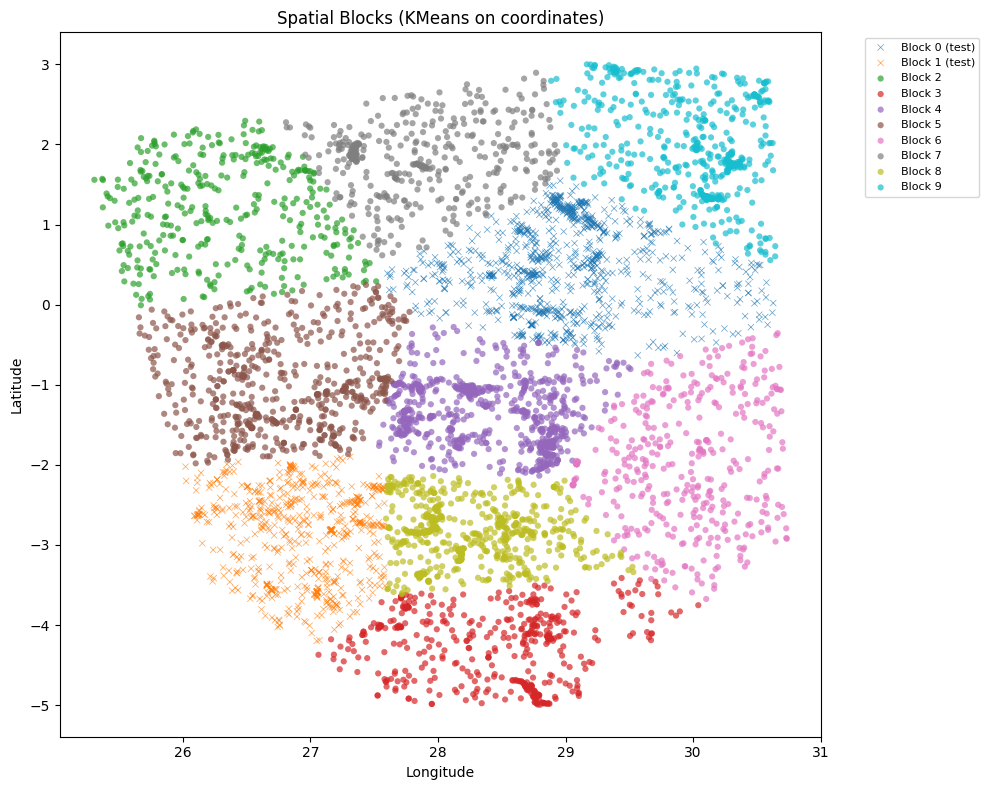

In [6]:
# Visualise spatial blocks
fig, ax = plt.subplots(figsize=(10, 8))

for block in range(N_CLUSTERS):
    mask = block_ids == block
    is_test = block in TEST_BLOCKS
    marker = "x" if is_test else "o"
    edgecolor = "red" if is_test else "none"
    ax.scatter(
        coords[mask, 1],  # lon
        coords[mask, 0],  # lat
        c=[plt.cm.tab10(block / N_CLUSTERS)] * mask.sum(),
        marker=marker,
        s=20,
        alpha=0.7,
        edgecolors=edgecolor,
        linewidths=0.5,
        label=f"Block {block}{' (test)' if is_test else ''}",
    )

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Spatial Blocks (KMeans on coordinates)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 4. Train Random Forest

In [7]:
rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)
rf.fit(X_train, y_train)

rf_train_acc = accuracy_score(y_train, rf.predict(X_train))
print(f"Random Forest training accuracy: {rf_train_acc:.4f}")

Random Forest training accuracy: 1.0000


## 5. Train XGBoost

In [8]:
xgb = XGBClassifier(
    n_estimators=200,
    scale_pos_weight=1,
    random_state=42,
    eval_metric="logloss",
)
xgb.fit(X_train, y_train)

xgb_train_acc = accuracy_score(y_train, xgb.predict(X_train))
print(f"XGBoost training accuracy: {xgb_train_acc:.4f}")

XGBoost training accuracy: 1.0000


## 5b. Hyperparameter Tuning (RandomizedSearchCV + GroupKFold)

We tune both models using spatial cross-validation to avoid overfitting to spatially correlated data. `GroupKFold` ensures no spatial block appears in both train and validation within a fold.

In [12]:
import warnings
warnings.filterwarnings("ignore", message=".*sklearn.utils.parallel.delayed.*")

gkf_tune = GroupKFold(n_splits=8)

# --- Random Forest tuning ---
rf_param_dist = {
    "n_estimators": [200, 400, 600],
    "max_depth": [10, 20, 30, None],
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt", "log2", 0.3],
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", random_state=42, n_jobs=1),
    param_distributions=rf_param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=gkf_tune,
    random_state=42,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train, groups=blocks_train)

print("Random Forest best params:", rf_search.best_params_)
print(f"Random Forest best CV AUC:  {rf_search.best_score_:.4f}")

# --- XGBoost tuning ---
xgb_param_dist = {
    "n_estimators": [200, 400, 600],
    "max_depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
}

xgb_search = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric="logloss", n_jobs=1),
    param_distributions=xgb_param_dist,
    n_iter=20,
    scoring="roc_auc",
    cv=gkf_tune,
    random_state=42,
    n_jobs=-1,
)
xgb_search.fit(X_train, y_train, groups=blocks_train)

print(f"\nXGBoost best params: {xgb_search.best_params_}")
print(f"XGBoost best CV AUC:  {xgb_search.best_score_:.4f}")

# Retrain final models with best params (now with full n_jobs for final fit)
rf = rf_search.best_estimator_
rf.n_jobs = -1
xgb = xgb_search.best_estimator_

print(f"\nModels retrained with tuned hyperparameters.")

Random Forest best params: {'n_estimators': 200, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 30}
Random Forest best CV AUC:  0.7667

XGBoost best params: {'subsample': 0.9, 'n_estimators': 400, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.7}
XGBoost best CV AUC:  0.7674

Models retrained with tuned hyperparameters.


## 6. Spatial Cross-Validation

We evaluate generalisation on the **training** set using `GroupKFold` where each fold holds out one or more spatial blocks. This simulates the model predicting in a region it has never seen, which is the realistic deployment scenario.

We report **ROC AUC** because the dataset may be imbalanced and AUC is threshold-independent.

In [13]:
gkf = GroupKFold(n_splits=8)

rf_cv_scores = cross_val_score(
    rf, X_train, y_train,
    cv=gkf, groups=blocks_train,
    scoring="roc_auc", n_jobs=-1,
)

xgb_cv_scores = cross_val_score(
    xgb, X_train, y_train,
    cv=gkf, groups=blocks_train,
    scoring="roc_auc", n_jobs=-1,
)

print("Spatial CV ROC AUC (GroupKFold, 8 splits)")
print(f"  Random Forest : {rf_cv_scores.mean():.4f} +/- {rf_cv_scores.std():.4f}")
print(f"  XGBoost       : {xgb_cv_scores.mean():.4f} +/- {xgb_cv_scores.std():.4f}")
print(f"\nPer-fold RF  : {np.round(rf_cv_scores, 4)}")
print(f"Per-fold XGB : {np.round(xgb_cv_scores, 4)}")

Spatial CV ROC AUC (GroupKFold, 8 splits)
  Random Forest : 0.7667 +/- 0.0674
  XGBoost       : 0.7674 +/- 0.0670

Per-fold RF  : [0.7031 0.8023 0.8295 0.6523 0.6972 0.848  0.7893 0.8118]
Per-fold XGB : [0.7204 0.7814 0.8414 0.6735 0.6914 0.8831 0.7734 0.7746]


## 7. Feature Importance

We expect indices derived from **NDVI** (vegetation stress), **BSI** (bare soil), and the **SWIR bands (B11, B12)** to rank among the most important features, as mining sites typically exhibit exposed soil, reduced vegetation, and distinctive short-wave infrared reflectance.

In [14]:
rf_importances = rf.feature_importances_
xgb_importances = xgb.feature_importances_

# Sort by RF importance for consistent ordering
sort_idx = np.argsort(rf_importances)[::-1]
sorted_names = [feature_names[i] for i in sort_idx]
rf_sorted = rf_importances[sort_idx]
xgb_sorted = xgb_importances[sort_idx]

# Display top 15
top_n = min(15, len(feature_names))
print(f"Top {top_n} features (by Random Forest importance):")
for i in range(top_n):
    print(f"  {i+1:2d}. {sorted_names[i]:30s}  RF={rf_sorted[i]:.4f}  XGB={xgb_sorted[i]:.4f}")

Top 15 features (by Random Forest importance):
   1. elevation                       RF=0.1301  XGB=0.0767
   2. B5                              RF=0.1036  XGB=0.1915
   3. B3                              RF=0.0996  XGB=0.1894
   4. B4                              RF=0.0835  XGB=0.0611
   5. NDWI                            RF=0.0680  XGB=0.0616
   6. B2                              RF=0.0651  XGB=0.0535
   7. NDVI                            RF=0.0617  XGB=0.0457
   8. B12                             RF=0.0591  XGB=0.0444
   9. BSI                             RF=0.0529  XGB=0.0358
  10. B11                             RF=0.0516  XGB=0.0422
  11. B6                              RF=0.0507  XGB=0.0384
  12. slope                           RF=0.0424  XGB=0.0421
  13. B8                              RF=0.0349  XGB=0.0352
  14. B8A                             RF=0.0345  XGB=0.0384
  15. B7                              RF=0.0328  XGB=0.0294


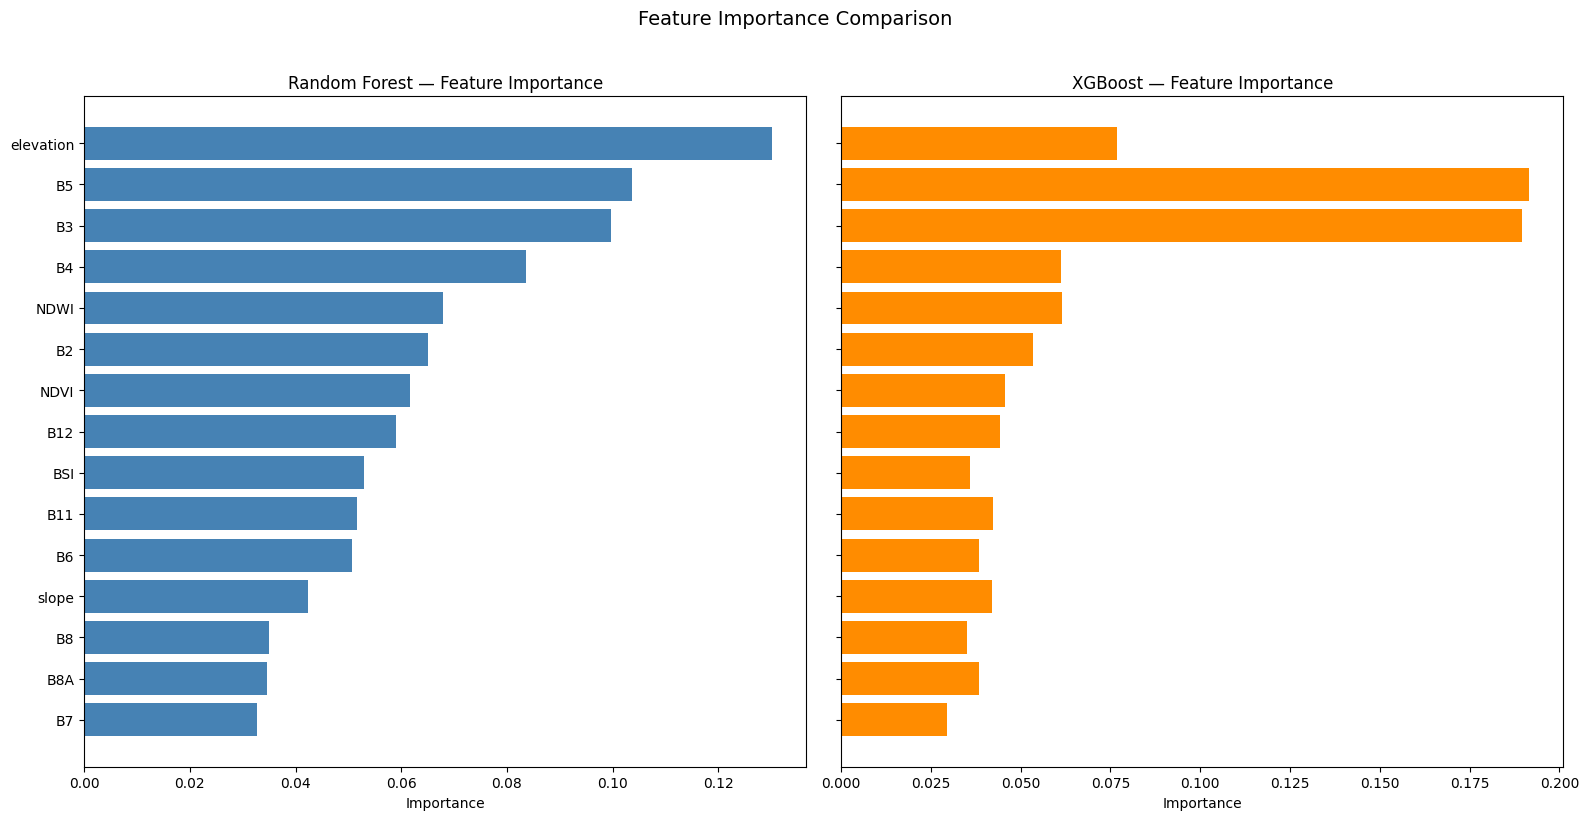

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# Random Forest
axes[0].barh(range(top_n), rf_sorted[:top_n][::-1], color="steelblue")
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(sorted_names[:top_n][::-1])
axes[0].set_xlabel("Importance")
axes[0].set_title("Random Forest — Feature Importance")

# XGBoost
axes[1].barh(range(top_n), xgb_sorted[:top_n][::-1], color="darkorange")
axes[1].set_yticks(range(top_n))
axes[1].set_yticklabels(sorted_names[:top_n][::-1])
axes[1].set_xlabel("Importance")
axes[1].set_title("XGBoost — Feature Importance")

plt.suptitle("Feature Importance Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 8. Save Models

Persist both trained models and the feature name list so that downstream notebooks (evaluation, prediction) can reload them without retraining.

In [17]:
models_dir = "../models"
os.makedirs(models_dir, exist_ok=True)

rf_path = os.path.join(models_dir, "random_forest.joblib")
xgb_path = os.path.join(models_dir, "xgboost_model.joblib")
features_path = os.path.join(models_dir, "feature_names.joblib")

joblib.dump(rf, rf_path)
joblib.dump(xgb, xgb_path)
joblib.dump(feature_names, features_path)

print(f"Random Forest saved to {rf_path}")
print(f"XGBoost saved to       {xgb_path}")
print(f"Feature names saved to {features_path}")
print(f"\nNumber of features: {len(feature_names)}")

Random Forest saved to ../models/random_forest.joblib
XGBoost saved to       ../models/xgboost_model.joblib
Feature names saved to ../models/feature_names.joblib

Number of features: 16


---

### Summary

| Step | Detail |
|------|--------|
| Data | `features_merged.csv` loaded, non-feature columns dropped |
| Spatial split | KMeans (k=10) on lat/lon; blocks 0 & 1 held out as test |
| Random Forest | 200 trees, balanced class weights |
| XGBoost | 200 rounds, logloss metric |
| Spatial CV | GroupKFold (8 splits) on training blocks; ROC AUC reported |
| Feature importance | Side-by-side bar charts; expect NDVI, BSI, SWIR bands to dominate |
| Artefacts | `random_forest.joblib`, `xgboost_model.joblib`, `feature_names.joblib` |

Proceed to **05 — Model Evaluation** for test-set metrics, confusion matrices, and spatial error analysis.